In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from tqdm import tqdm

c:\Users\rishi\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [2]:
TrainEEGPath = r"C:\Engineering\Capstone\ProcessEEG\DenoisedEEG_train.pth"
ImageFolderPath = r"C:\Engineering\Capstone\Imagenet_Images"

In [3]:

class EEGImageDataset(Dataset):
    def __init__(self, eeg_path, image_folder, transform=None):
        self.eeg_data = torch.load(eeg_path)
        self.image_folder = image_folder
        self.image_files = sorted(os.listdir(image_folder))[0:11000]
        self.transform = transform
        print(len(self.eeg_data), len(self.image_files))
        assert len(self.eeg_data) == len(self.image_files), "EEG and image count mismatch"

    def __len__(self):
        return len(self.eeg_data)

    def __getitem__(self, idx):
        eeg = self.eeg_data[idx]
        img_path = os.path.join(self.image_folder, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return eeg.float(), image.float()


transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = EEGImageDataset(TrainEEGPath, ImageFolderPath, transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


11000 11000


In [ ]:

# Generator
class EEGGenerator(nn.Module):
    def __init__(self, eeg_seq_len=360, eeg_channels=5):
        super().__init__()
        self.latent_dim = 256
        self.encoder = nn.Sequential(
            nn.Linear(eeg_seq_len * eeg_channels, 512),
            nn.ReLU(),
            nn.Linear(512, self.latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(self.latent_dim, 512*4*4),
            nn.ReLU(),
            nn.Unflatten(1, (512,4,4)),
            nn.ConvTranspose2d(512,256,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(256,128,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1), nn.Tanh()
        )

    def forward(self, eeg):
        x = eeg.view(eeg.size(0), -1)
        latent = self.encoder(x)
        img = self.decoder(latent)
        return img


# Discriminator
class EEGDiscriminator1(nn.Module):
    def __init__(self, eeg_seq_len=360, eeg_channels=5, img_size=64):
        super().__init__()
        self.img_conv = nn.Sequential(
            nn.Conv2d(3,64,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2)
        )
        self.eeg_fc = nn.Sequential(
            nn.Linear(eeg_seq_len*eeg_channels, 256),
            nn.LeakyReLU(0.2)
        )
        # Placeholder for final linear, will initialize dynamically
        self.final = None
        self.img_size = img_size

    def forward(self, eeg, img):
        img_feat = self.img_conv(img)
        img_feat_flat = img_feat.view(img_feat.size(0), -1)
        if self.final is None:
            # initialize final layer dynamically
            self.final = nn.Linear(img_feat_flat.size(1) + 256, 1).to(img.device)
        eeg_feat = self.eeg_fc(eeg.view(eeg.size(0), -1))
        combined = torch.cat([img_feat_flat, eeg_feat], dim=1)
        return self.final(combined)

class EEGDiscriminator(nn.Module):
    def __init__(self, eeg_seq_len=360, eeg_channels=5, img_size=64):
        super().__init__()
        
        # Convolutional layers for image input
        self.img_conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), 
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), 
            nn.BatchNorm2d(128), 
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), 
            nn.BatchNorm2d(256), 
            nn.LeakyReLU(0.2)
        )
        
        # Fully connected layers for EEG input
        self.eeg_fc = nn.Sequential(
            nn.Linear(eeg_seq_len * eeg_channels, 256),
            nn.LeakyReLU(0.2)
        )
        
        # Final layer for decision (real/fake)
        self.final = None
        self.img_size = img_size

    def forward(self, eeg, img):
        # If EEG input is None, skip processing it
        if eeg is None:
            eeg_feat = torch.zeros(img.size(0), 256).to(img.device)  # Create a zero tensor for EEG features
        else:
            eeg_feat = self.eeg_fc(eeg.view(eeg.size(0), -1))  # Process EEG data through fully connected layers
        
        # Process the image input through the convolutional layers
        img_feat = self.img_conv(img)
        img_feat_flat = img_feat.view(img_feat.size(0), -1)  # Flatten the image features
        
        # Dynamically initialize the final layer if not already done
        if self.final is None:
            self.final = nn.Linear(img_feat_flat.size(1) + 256, 1).to(img.device)
        
        # Combine EEG features with image features
        combined = torch.cat([img_feat_flat, eeg_feat], dim=1)
        
        # Final output (real/fake)
        output = self.final(combined)
        
        # Return both the final output and the intermediate image features
        return output, img_feat_flat, eeg_feat


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = EEGGenerator().to(device)
C = EEGDiscriminator().to(device)

optimizer_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.0,0.9))
optimizer_C = torch.optim.Adam(C.parameters(), lr=1e-4, betas=(0.0,0.9))

lambda_gp = 10
n_Discriminator = 5
num_epochs = 50



In [85]:
device

'cuda'

In [86]:
G.load_state_dict(torch.load("EEG_GAN_GP_Generator500.pth", map_location=device))
C.load_state_dict(torch.load("EEG_GAN_GP_Critic500.pth", map_location=device ), strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['final.weight', 'final.bias'])

In [87]:
num_epochs = 200

In [88]:
# Gradient Penalty
def gradient_penalty(Discriminator, real, fake, eeg, device="cuda"):
    alpha = torch.rand(real.size(0),1,1,1).to(device)
    interpolated = (alpha*real + (1-alpha)*fake).requires_grad_(True)
    mixed_scores = Discriminator(eeg, interpolated)
    grad = torch.autograd.grad(
        outputs=mixed_scores, inputs=interpolated,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grad = grad.view(grad.size(0), -1)
    gp = ((grad.norm(2, dim=1)-1)**2).mean()
    return gp


In [ ]:
import torch
import torch.nn.functional as F

def contrastive_loss(features_real, features_fake, margin=1.0):
    # minimize the distance between positive pairs (real image and real EEG),
    # and maximize the distance between negative pairs (real image and fake EEG).
    distance = F.pairwise_distance(features_real, features_fake, p=2)
    loss = torch.mean((1 - margin) * distance + torch.relu(distance - margin))
    return loss

# Feature matching loss: Measure the L2 distance between features of real and fake images
def feature_matching_loss(real_img, fake_img, discriminator):
  
    real_output, real_img_feat, _ = discriminator(None, real_img)  
    fake_output, fake_img_feat, _ = discriminator(None, fake_img) 
    
    # Calculate the L2 distance between the feature maps of real and fake images
    fm_loss = F.mse_loss(real_img_feat, fake_img_feat)
    
    return fm_loss

# Generator's adversarial loss
def adversarial_loss(discriminator, eeg, fake_img):
    output, _,_ = discriminator(eeg, fake_img) 
    return -output.mean()

# Cycle consistency loss (if using a CycleGAN-like architecture)
def cycle_consistency_loss(real_img, cycle_img):
    return F.l1_loss(real_img, cycle_img)


In [ ]:
# Training Loop
for epoch in range(num_epochs):
    loop = tqdm(train_loader)
    for i, (eeg, real_img) in enumerate(loop):
        batch_size = eeg.size(0)
        eeg, real_img = eeg.to(device), real_img.to(device)


        for _ in range(n_Discriminator):
            fake_img = G(eeg).detach()  
            C.zero_grad()

            features_real, real_img_feat, _ = C(eeg, real_img)  
            features_fake, fake_img_feat, _ = C(eeg, fake_img)  

            # Apply contrastive loss
            loss_C_contrastive = contrastive_loss(features_real, features_fake)

            # Adversarial loss
            loss_D_real = F.binary_cross_entropy_with_logits(features_real, torch.ones_like(features_real))
            loss_D_fake = F.binary_cross_entropy_with_logits(features_fake, torch.zeros_like(features_fake))
            loss_D = (loss_D_real + loss_D_fake) / 2

            # Total loss
            loss_C = loss_C_contrastive + loss_D
            loss_C.backward()
            optimizer_C.step()

        # Train Generator
        G.zero_grad()
        fake_img = G(eeg)
        
        # Adversarial loss for generator
        loss_G_adv = adversarial_loss(C, eeg, fake_img)

        # Feature matching loss 
        loss_G_feature_matching = feature_matching_loss(real_img, fake_img, C)

        # Combine all losses
        total_loss_G = loss_G_adv + 0.5 * loss_G_feature_matching

        total_loss_G.backward()
        optimizer_G.step()

        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss_C=loss_C.item(), loss_G=total_loss_G.item())


Epoch [1/200]:   0%|          | 1/688 [00:00<09:09,  1.25it/s, loss_C=65.7, loss_G=2.48e+3]


KeyboardInterrupt: 

In [ ]:
G.train()
C.train()
# Training Loop
for epoch in range(num_epochs):
    loop = tqdm(train_loader)
    for i, (eeg, real_img) in enumerate(loop):
        batch_size = eeg.size(0)
        # eeg = eeg.view(eeg.size(0), eeg.size(2), eeg.size(1), 1)  # [batch_size, eeg_channels, eeg_seq_len, 1]
        eeg, real_img = eeg.to(device), real_img.to(device)

        for _ in range(n_Discriminator):
            fake_img = G(eeg).detach()
            C.zero_grad()
            Discriminator_real = C(eeg, real_img)
            Discriminator_fake = C(eeg, fake_img)
            gp = gradient_penalty(C, real_img, fake_img, eeg, device)
            loss_C = -(Discriminator_real.mean() - Discriminator_fake.mean()) + lambda_gp * gp
            loss_C.backward()
            optimizer_C.step()

        # Train Generator
        G.zero_grad()
        fake_img = G(eeg)
        loss_G = -C(eeg, fake_img).mean()
        loss_G.backward()
        optimizer_G.step()

        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss_C=loss_C.item(), loss_G=loss_G.item())                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load generator
device = "cuda" if torch.cuda.is_available() else "cpu"
G = EEGGenerator().to(device)
G.load_state_dict(torch.load("EEG_GAN_GP_Generator_loss_502.pth", map_location=device))
G.eval()

# Load test EEG and test images
TestEEGPath = r"C:\Engineering\Capstone\ProcessEEG\DenoisedEEG_test.pth"
ImageFolderPath = r"C:\Engineering\Capstone\Imagenet_Images"

test_eeg = torch.load(TestEEGPath).to(device).float()
test_image_files = sorted(os.listdir(ImageFolderPath))[11000:]  # test index 11000 onward

batch_size = 16
test_dataset = TensorDataset(test_eeg)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Generate and display
try:
    with torch.no_grad():
        idx_offset = 0
        for batch_idx, (eeg_batch,) in enumerate(test_loader):
            eeg_batch = eeg_batch.to(device)
            fake_imgs = G(eeg_batch)
            fake_imgs = (fake_imgs + 1)/2  # [-1,1] -> [0,1]

            for i in range(fake_imgs.size(0)):
                # Load corresponding real image  
                real_img_path = os.path.join(ImageFolderPath, test_image_files[idx_offset + i])
                real_img = Image.open(real_img_path).convert("RGB")
                real_img = real_img.resize((64,64))

                # Convert fake image to PIL
                fake_img = transforms.ToPILImage()(fake_imgs[i].cpu())

                # Display side by side
                fig, axs = plt.subplots(1,2, figsize=(6,3))
                axs[0].imshow(real_img)
                axs[0].set_title("Real Image")
                axs[0].axis("off")
                axs[1].imshow(fake_img)
                axs[1].set_title("Generated Image")
                axs[1].axis("off")
                plt.show()

            idx_offset += eeg_batch.size(0)
except Exception as e:
    print(e)
    pass


In [ ]:

# =========================
# Save Models
# =========================
torch.save(G.state_dict(), "EEG_GAN_GP_Generator_loss_502.pth")
torch.save(C.state_dict(), "EEG_GAN_GP_Critic_loss_502.pth")


torch.Size([1199, 360, 5])


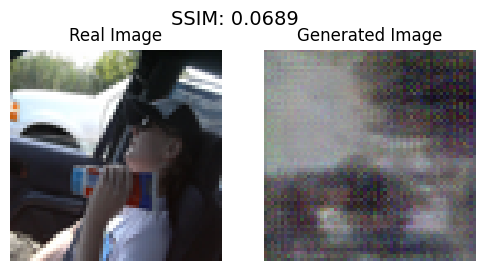

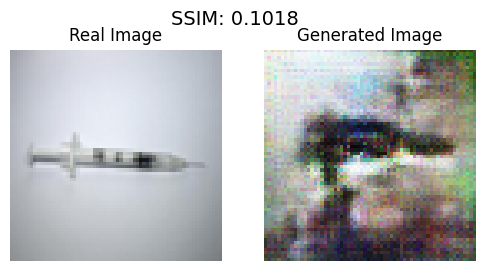

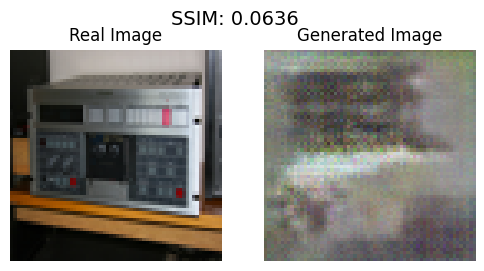

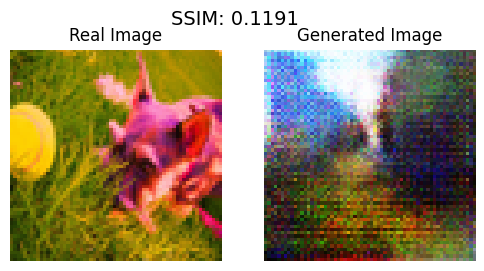

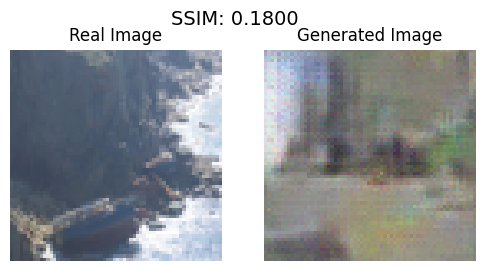

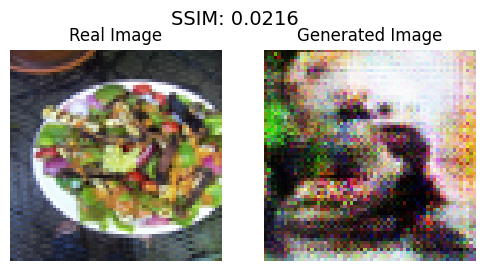

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
from skimage.metrics import structural_similarity as ssim
import numpy as np

# Load generator
device = "cuda" if torch.cuda.is_available() else "cpu"
G = EEGGenerator().to(device)
G.load_state_dict(torch.load("EEG_GAN_GP_Generator_loss_502.pth", map_location=device))
G.eval()

# Load test EEG and test images
TestEEGPath = r"C:\Engineering\Capstone\ProcessEEG\DenoisedEEG_test.pth"
ImageFolderPath = r"C:\Engineering\Capstone\Imagenet_Images"

test_eeg = torch.load(TestEEGPath).to(device).float()
print(test_eeg.shape)
test_image_files = sorted(os.listdir(ImageFolderPath))[11000:]  # pick images from index 11000 onward

# Create DataLoader
batch_size = 16
test_dataset = TensorDataset(test_eeg)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Function to generate a single image based on test number


def generate_single_image(test_number: int):
    try:
       
        eeg_sample = test_eeg[test_number].unsqueeze(0).to(device)  # Add batch dimension
        with torch.no_grad():
            fake_img = G(eeg_sample)
            fake_img = (fake_img + 1) / 2  # Normalize to [0, 1]
        
        # Convert fake image to PIL image
        fake_img_pil = transforms.ToPILImage()(fake_img.squeeze(0).cpu())

        # Load corresponding real image
        real_img_path = os.path.join(ImageFolderPath, test_image_files[test_number])
        real_img = Image.open(real_img_path).convert("RGB")
        real_img = real_img.resize((64, 64))

        #for SSIM calculation
        real_img_np = np.array(real_img.convert("L"))  # Convert image to grayscale
        fake_img_np = np.array(fake_img_pil.convert("L"))  

        ssim_value, _ = ssim(real_img_np, fake_img_np, full=True)

        # Display the real and fake image side by side with SSIM score
        fig, axs = plt.subplots(1, 2, figsize=(6, 3))
        axs[0].imshow(real_img)
        axs[0].set_title("Real Image")
        axs[0].axis("off")
        axs[1].imshow(fake_img_pil)
        axs[1].set_title("Generated Image")
        axs[1].axis("off")

        
        plt.suptitle(f"SSIM: {ssim_value:.4f}", fontsize=14)

        plt.show()

    except Exception as e:
        print(f"Error generating image for test number {test_number}: {e}")



generate_single_image(21)
generate_single_image(52)
generate_single_image(89)
generate_single_image(119)
generate_single_image(487)


In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np
from tqdm import tqdm
from PIL import Image

def compute_batch_ssim(test_eeg, test_image_files, image_folder, generator, device="cpu"):
    """
    Computes SSIM for all EEG->image generations in the dataset.
    Does NOT display images. Returns mean SSIM + list of all scores.
    """
    generator.eval()
    all_ssim_scores = []

    for i in tqdm(range(len(test_eeg)), desc="Computing SSIM"):
        try:

            eeg_sample = test_eeg[i].unsqueeze(0).to(device)

            with torch.no_grad():
                fake_img = generator(eeg_sample)
                fake_img = (fake_img + 1) / 2  # Normalize to [0,1]

            fake_img_pil = transforms.ToPILImage()(fake_img.squeeze(0).cpu())

            real_img_path = os.path.join(image_folder, test_image_files[i])
            real_img = Image.open(real_img_path).convert("RGB").resize((64, 64))

            real_np = np.array(real_img.convert("L"))
            fake_np = np.array(fake_img_pil.convert("L"))

            ssim_value, _ = ssim(real_np, fake_np, full=True)
            all_ssim_scores.append(ssim_value)

        except Exception as e:
            print(f"Error at index {i}: {e}")
            all_ssim_scores.append(None)

    # Drop None values
    filtered_scores = [s for s in all_ssim_scores if s is not None]

    mean_ssim = np.mean(filtered_scores)
    return mean_ssim, filtered_scores


In [14]:
mean_ssim, ssim_scores = compute_batch_ssim(
    test_eeg=test_eeg,
    test_image_files=test_image_files,
    image_folder=ImageFolderPath,
    generator=G,
    device=device
)

print("Average SSIM:", mean_ssim)
print("Number of samples:", len(ssim_scores))


Computing SSIM: 100%|██████████| 1199/1199 [00:07<00:00, 165.56it/s]

Error at index 1190: list index out of range
Error at index 1191: list index out of range
Error at index 1192: list index out of range
Error at index 1193: list index out of range
Error at index 1194: list index out of range
Error at index 1195: list index out of range
Error at index 1196: list index out of range
Error at index 1197: list index out of range
Error at index 1198: list index out of range
Average SSIM: 0.05083427142672744
Number of samples: 1190
